# Titanic Survival Analysis — Exploratory Data Analysis 

## Objective

The objective of this notebook is to investigate the characteristics associated with passenger survival aboard the Titanic.

The analysis aims to:

- Understand the distributions of individual variables.
- Examine relationships between predictors and the target variable.
- Explore interactions among features.
- Identify patterns and potential predictive signals.
- Generate hypotheses for feature engineering.
- Produce insights that will guide subsequent model development.


## Import Required Libraries

In [35]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

## Dataset Overview

The cleaned dataset produced during the data wrangling stage is used for exploratory analysis.

Objectives:

- Load the processed dataset.
- Examine its structure.
- Verify dimensions and datatypes.
- Establish the analytical foundation for subsequent sections.

In [36]:
df = pd.read_csv('../data/processed/titanic_cleaned.csv')

df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,S


In [37]:
print(f"Dataset Shape: {df.shape}")

Dataset Shape: (891, 9)


In [38]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    str    
 3   Sex       891 non-null    str    
 4   Age       891 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Fare      891 non-null    float64
 8   Embarked  891 non-null    str    
dtypes: float64(2), int64(4), str(3)
memory usage: 62.8 KB


### Observations

- The dataset contains cleaned observations from the Titanic passenger manifest.
- Missing values have been addressed during preprocessing.
- Features such as `Cabin`, `Ticket`, and `PassengerId` were removed.
- The dataset is ready for exploratory analysis.

## Target Variable Analysis

Understanding the target variable is essential before analyzing predictor relationships.

Questions:

- How many passengers survived?
- Is the target variable balanced?
- What baseline class distribution exists?

These insights influence model evaluation and metric selection.

In [39]:
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [40]:
survival_rate = df['Survived'].value_counts(normalize = True) * 100
survival_rate

Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64

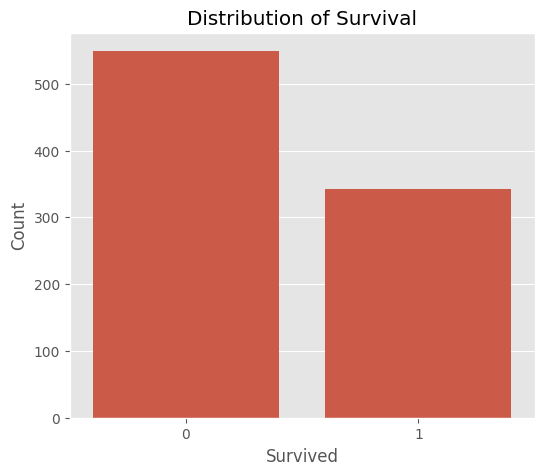

In [41]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="Survived"
)

plt.title("Distribution of Survival")
plt.xlabel("Survived")
plt.ylabel("Count")

plt.show()

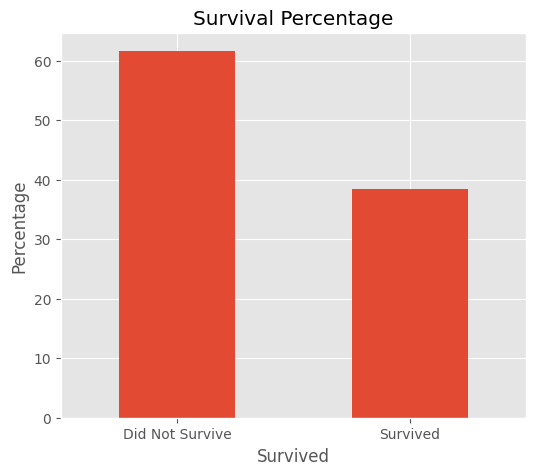

In [42]:
survival_percentage = (
    df["Survived"]
    .value_counts(normalize=True)
    .sort_index()*100
)

plt.figure(figsize=(6,5))

survival_percentage.plot(
    kind="bar"
)

plt.xticks(
    [0,1],
    ["Did Not Survive","Survived"],
    rotation=0
)

plt.ylabel("Percentage")
plt.title("Survival Percentage")

plt.show()

### Interpretation

The target variable is moderately imbalanced, with fatalities exceeding survivals. However, the imbalance is not severe enough to require special treatment at this stage.

### Key Insight

A larger proportion of passengers did not survive.

### Modeling Implication

Model evaluation should consider metrics beyond accuracy, such as precision, recall, and F1-score.

## Univariate Analysis

Univariate analysis focuses on understanding individual variables independently.

Objectives:

- Study distributions.
- Detect skewness.
- Understand spread and concentration.
- Identify dominant categories.
- Reveal potential feature engineering opportunities.

## Numerical Features

The numerical variables considered are:

- Age
- Fare
- SibSp
- Parch

For each variable, we investigate:

- Distribution
- Spread
- Skewness
- Potential outliers

In [43]:
numerical_columns = [
    "Age",
    "Fare",
    "SibSp",
    "Parch"
]

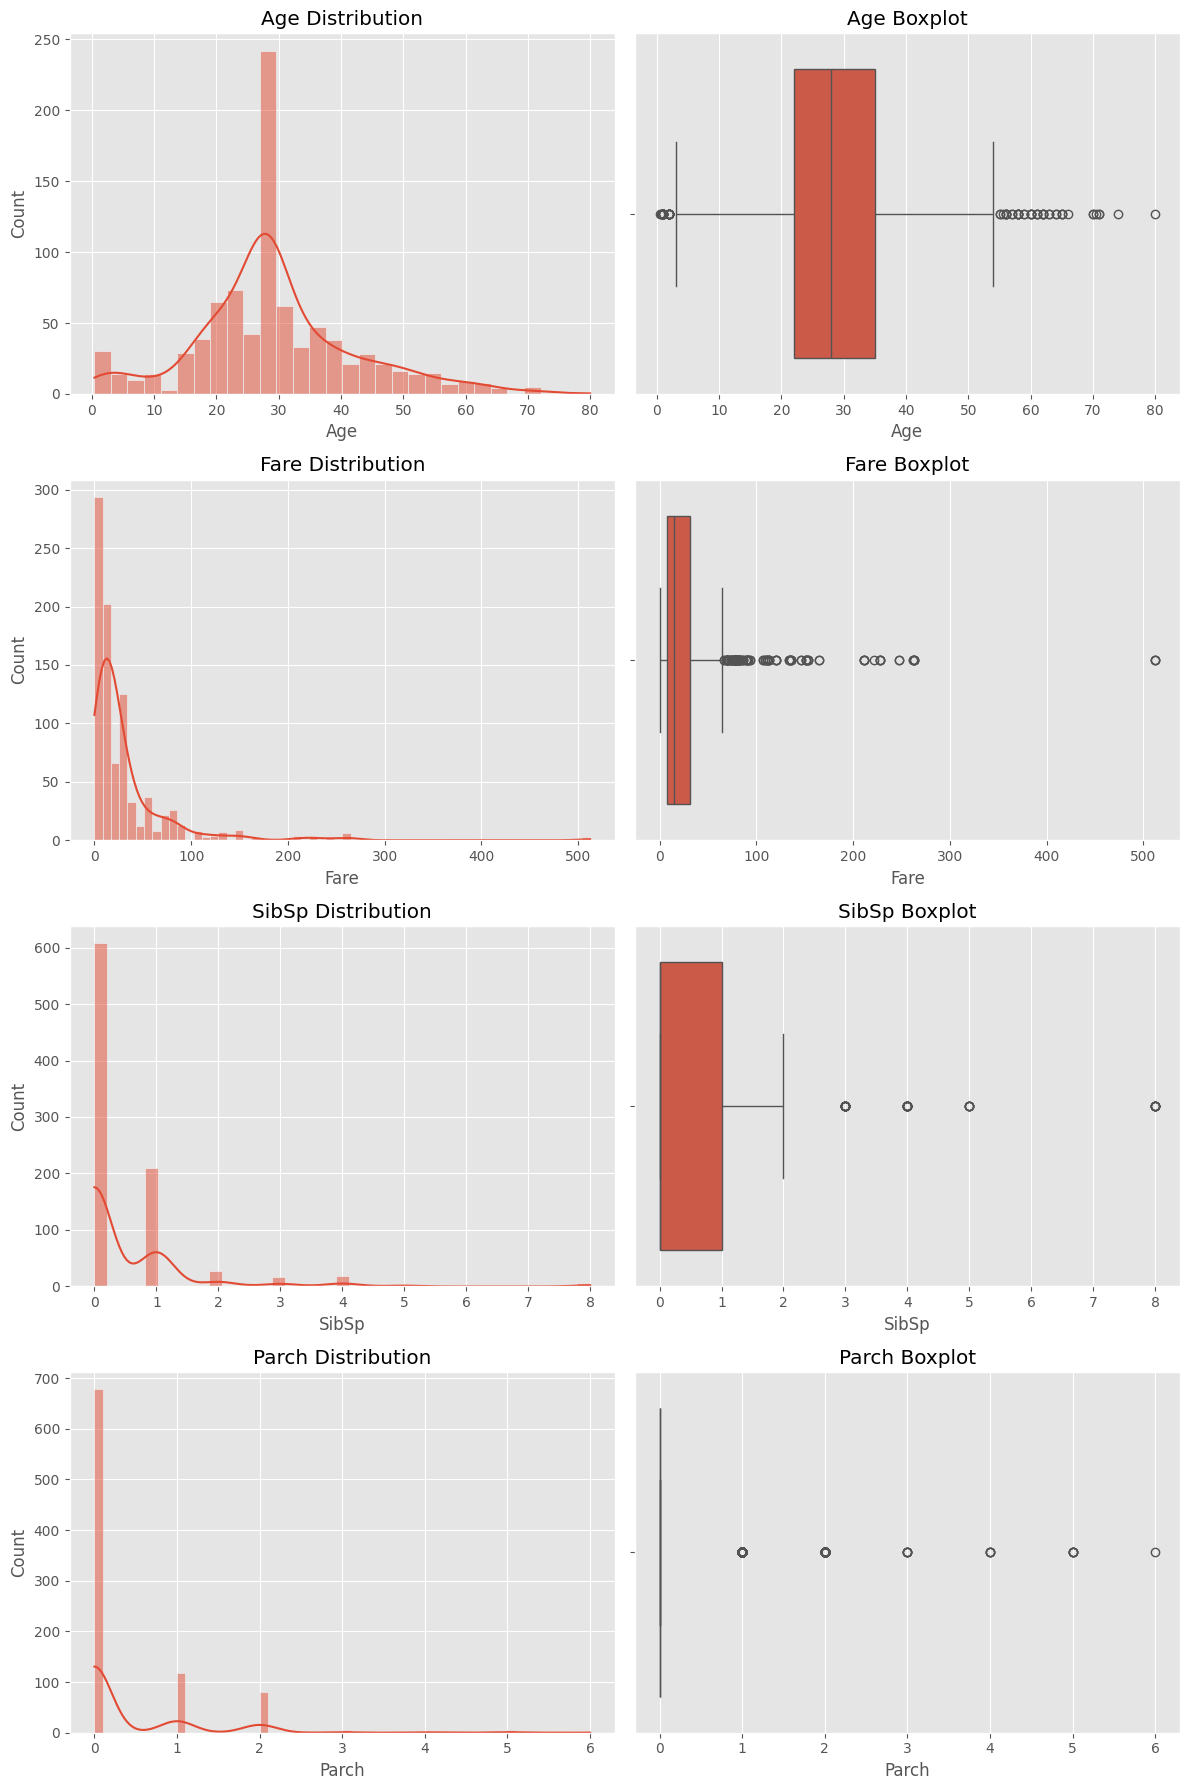

In [44]:
fig, axes = plt.subplots(
    nrows=4,
    ncols=2,
    figsize=(12,18)
)

for i, column in enumerate(numerical_columns):

    sns.histplot(
        data=df,
        x=column,
        kde=True,
        ax=axes[i,0]
    )

    axes[i,0].set_title(f"{column} Distribution")

    sns.boxplot(
        data=df,
        x=column,
        ax=axes[i,1]
    )

    axes[i,1].set_title(f"{column} Boxplot")

plt.tight_layout()

plt.show()

### Interpretation

- Age exhibits a roughly bell-shaped distribution with slight skewness.
- Fare displays strong positive skewness and contains extreme values.
- Most passengers travelled with few relatives aboard.
- Large family sizes are relatively uncommon.

### Key Insight

The Fare variable contains substantial variability and may capture socioeconomic information.

### Modeling Implication

Transformations or engineered features derived from family structure and fare may improve predictive performance.

## Categorical Features

The categorical variables examined are:

- Sex
- Pclass
- Embarked

The objective is to understand category frequencies and class distributions.

In [45]:
categorical_columns = [
    "Sex",
    "Pclass",
    "Embarked"
]

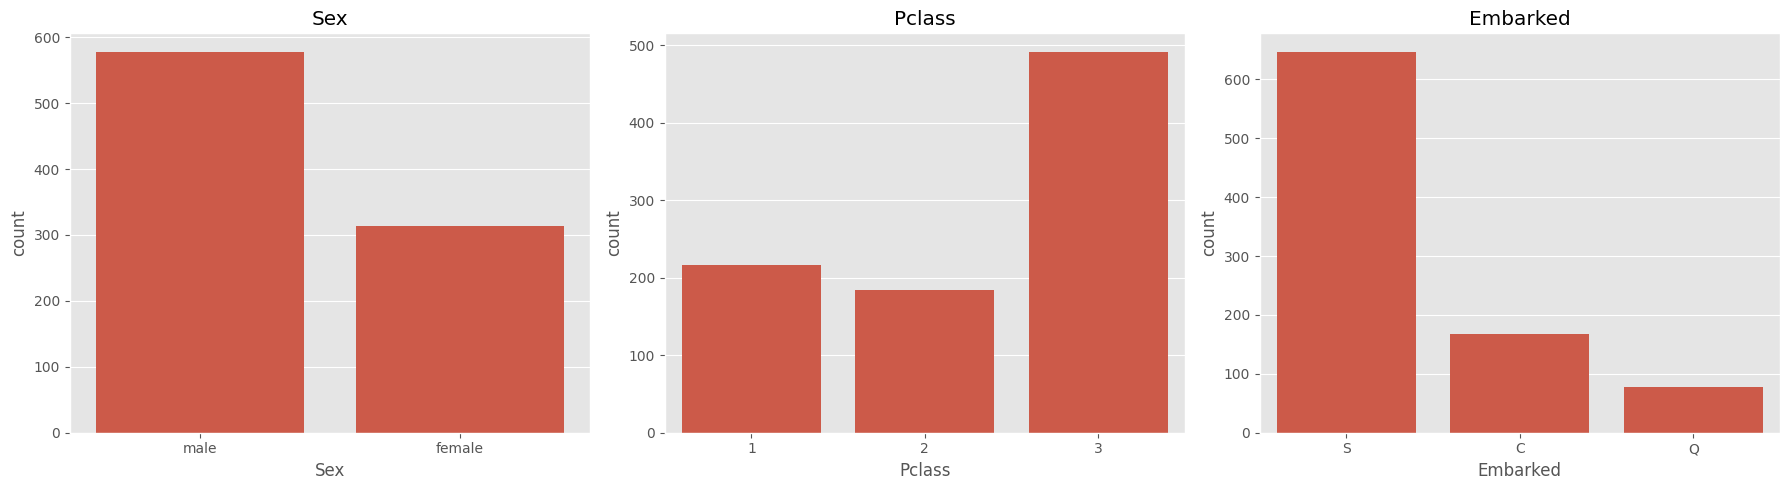

In [46]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(18,5)
)

for i, column in enumerate(categorical_columns):

    sns.countplot(
        data=df,
        x=column,
        ax=axes[i]
    )

    axes[i].set_title(column)

plt.tight_layout()

plt.show()

### Interpretation

- Male passengers outnumber female passengers.
- Third-class passengers constitute the largest group.
- Southampton ('S') is the most common embarkation port.

### Key Insight

The dataset contains noticeable category imbalance, particularly within passenger class and embarkation location.

### Modeling Implication

These categorical variables may contain valuable predictive information and should be retained during feature engineering.

## Bivariate Analysis

Understanding the relationship between individual predictors and survival is essential for identifying variables that may contribute to predictive performance.

This section focuses on how demographic characteristics, socioeconomic factors, and embarkation information are associated with passenger survival.

## Survival Patterns Across Gender

Gender has historically been regarded as one of the most important factors influencing survival during the Titanic disaster. Examining survival outcomes across gender provides insight into whether demographic characteristics contributed to differences in passenger outcomes.

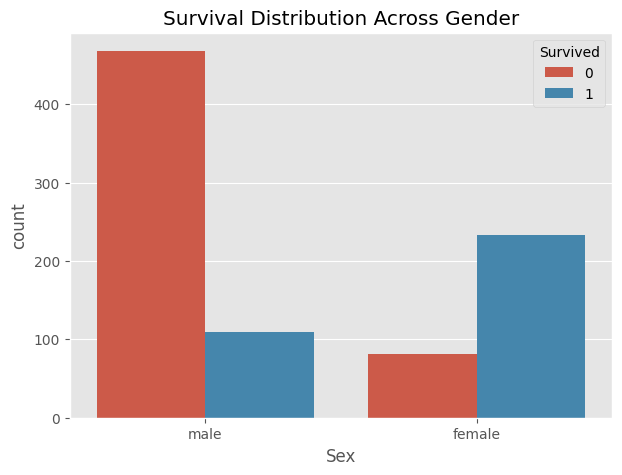

In [47]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Sex",
    hue="Survived"
)

plt.title("Survival Distribution Across Gender")

plt.show()

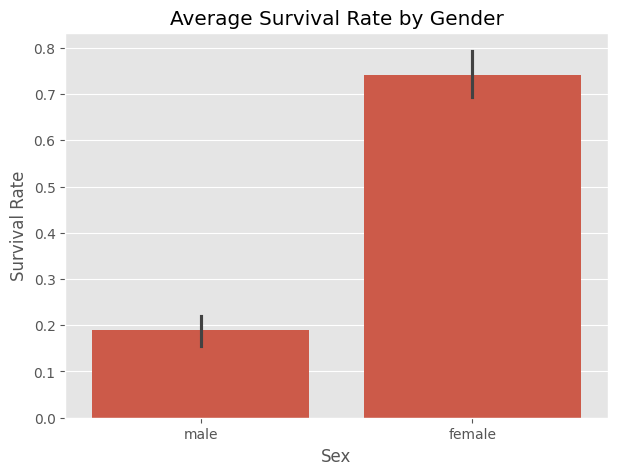

In [48]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=df,
    x="Sex",
    y="Survived"
)

plt.ylabel("Survival Rate")

plt.title("Average Survival Rate by Gender")

plt.show()

### Interpretation

Survival outcomes display substantial variation across gender. Female passengers experienced markedly higher survival rates than male passengers, indicating that demographic characteristics played an important role during evacuation.

The magnitude of this difference suggests that gender represents one of the strongest sources of predictive signal within the dataset and is expected to contribute significantly during model development.

## Survival Outcomes Across Passenger Classes

Passenger class serves as a proxy for socioeconomic status and may reflect differences in access to resources during evacuation. Analyzing survival patterns across classes helps evaluate whether social and economic factors influenced passenger outcomes.

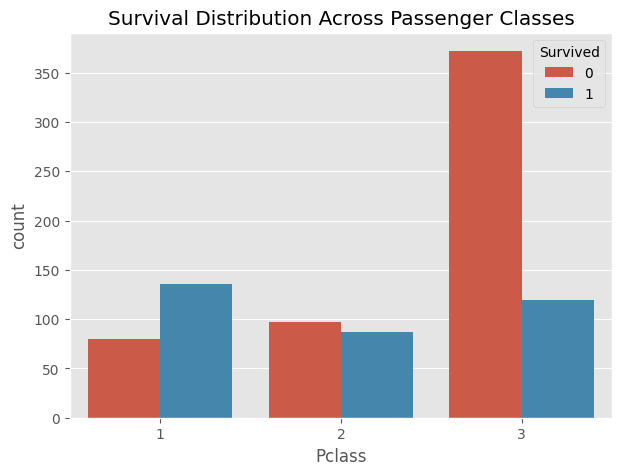

In [49]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Pclass",
    hue="Survived"
)

plt.title("Survival Distribution Across Passenger Classes")

plt.show()

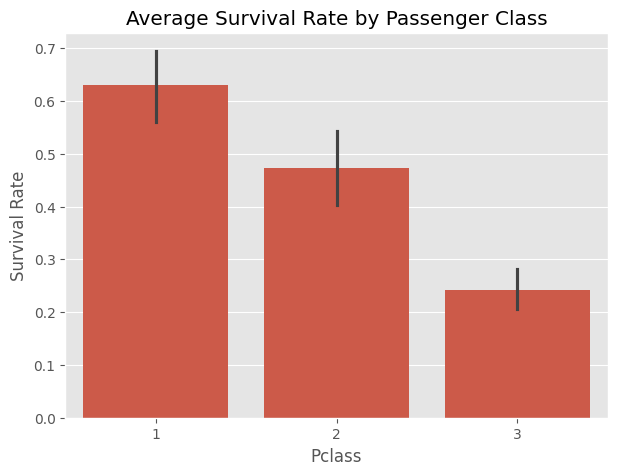

In [50]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=df,
    x="Pclass",
    y="Survived"
)

plt.ylabel("Survival Rate")

plt.title("Average Survival Rate by Passenger Class")

plt.show()

### Interpretation

Survival rates vary considerably across passenger classes. First-class passengers experienced the highest survival rates, while third-class passengers experienced the lowest.

These findings suggest that socioeconomic status and access to resources during evacuation may have influenced survival outcomes. The strength of this relationship indicates that passenger class contains substantial predictive information.

## Influence of Embarkation Port on Survival

Embarkation location may capture geographical and socioeconomic differences among passengers. Examining survival patterns across embarkation ports helps determine whether location-based differences are associated with survival.

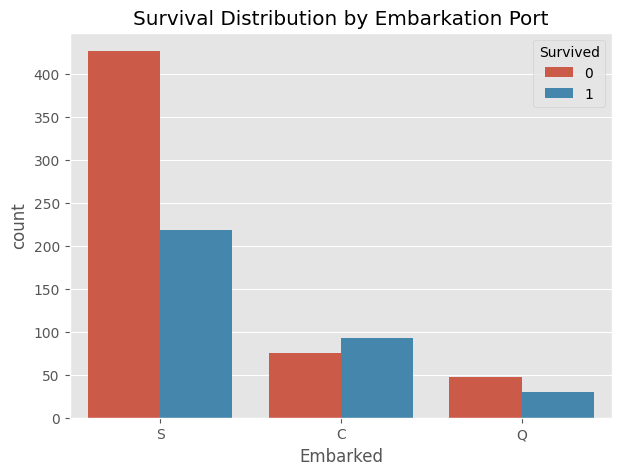

In [51]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Embarked",
    hue="Survived"
)

plt.title("Survival Distribution by Embarkation Port")

plt.show()

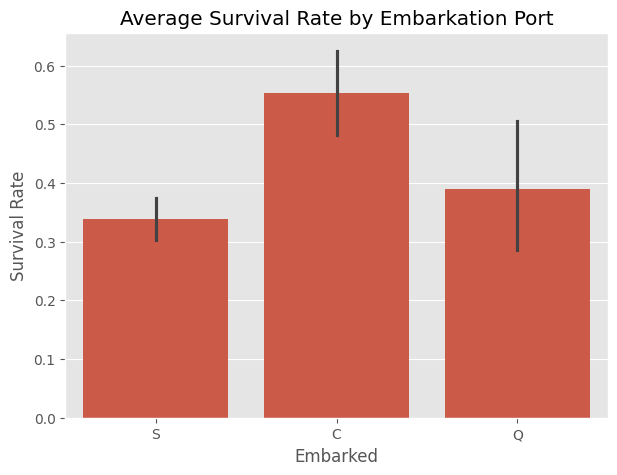

In [52]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=df,
    x="Embarked",
    y="Survived"
)

plt.ylabel("Survival Rate")

plt.title("Average Survival Rate by Embarkation Port")

plt.show()

### Interpretation

Survival rates differ across embarkation ports, although the observed differences are less pronounced compared to gender and passenger class.

While embarkation location appears to contain useful information, its predictive influence is expected to be weaker than that of demographic and socioeconomic variables.

## Age Distribution Among Survivors and Non-Survivors

Age is often associated with vulnerability and evacuation priority. Comparing age distributions between survivors and non-survivors helps assess whether age-related patterns exist within the dataset.

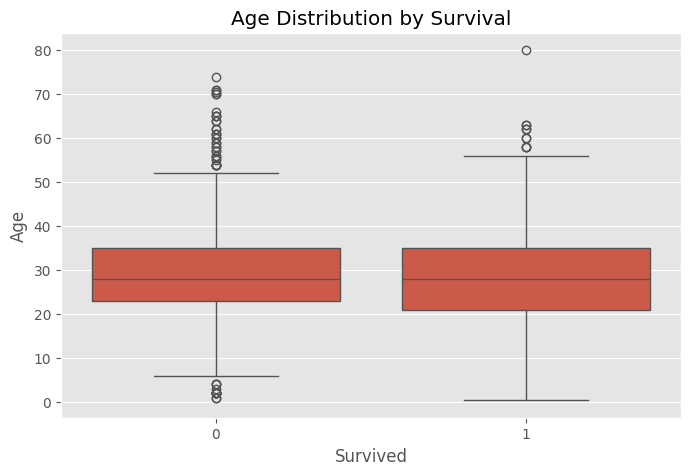

In [53]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Survived",
    y="Age"
)

plt.title("Age Distribution by Survival")

plt.show()

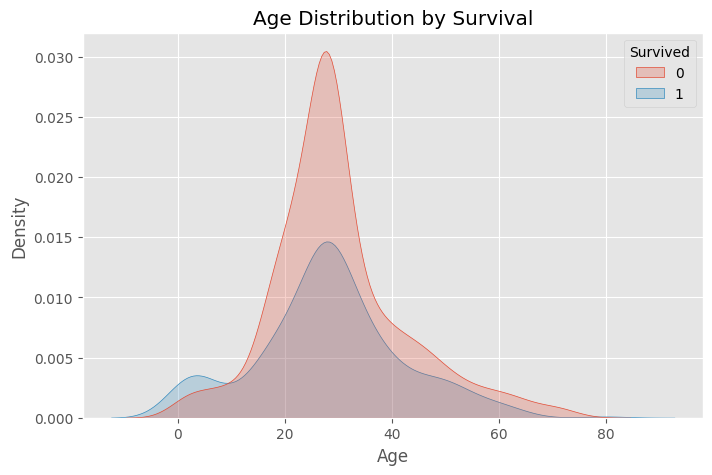

In [54]:
plt.figure(figsize=(8,5))

sns.kdeplot(
    data=df,
    x="Age",
    hue="Survived",
    fill=True
)

plt.title("Age Distribution by Survival")

plt.show()

### Interpretation

The age distributions of survivors and non-survivors overlap considerably, suggesting that age alone may not be a dominant predictor of survival. However, younger passengers appear to exhibit a modest survival advantage.

This pattern indicates that nonlinear age effects may exist, motivating the creation of age-related features during feature engineering.

## Relationship Between Ticket Fare and Survival

Ticket fare may reflect underlying socioeconomic status and differences in access to resources. Comparing fare distributions across survival outcomes helps assess whether economic factors influenced survival.

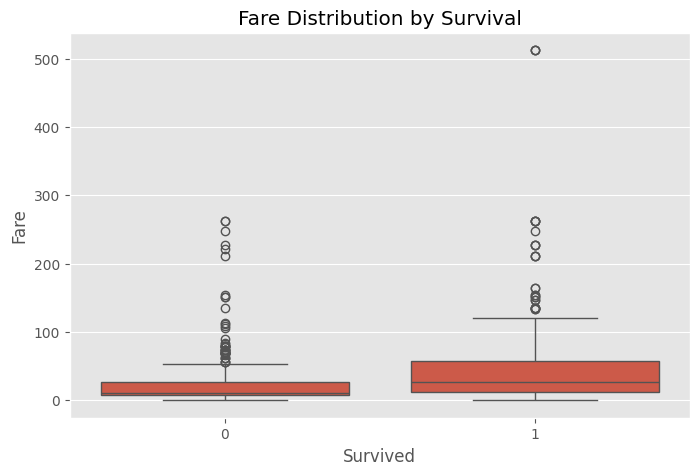

In [55]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Survived",
    y="Fare"
)

plt.title("Fare Distribution by Survival")

plt.show()

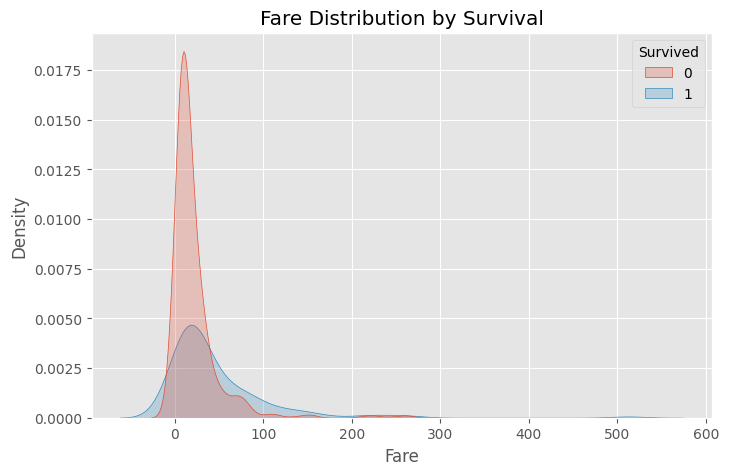

In [56]:
plt.figure(figsize=(8,5))

sns.kdeplot(
    data=df,
    x="Fare",
    hue="Survived",
    fill=True
)

plt.title("Fare Distribution by Survival")

plt.show()

### Interpretation

Passengers who survived generally paid higher fares than those who did not survive. Since ticket fare is closely associated with socioeconomic status, this pattern suggests that economic factors may have contributed to differences in survival outcomes.

The relationship between fare and survival indicates that fare contains meaningful predictive information and may interact with passenger class during model development.

## Feature Relationships

In addition to understanding relationships with the target variable, it is important to examine associations among predictors themselves.

These relationships provide insight into potential interactions, redundancy, and opportunities for feature engineering.

## Fare Distribution Across Passenger Classes

Since both fare and passenger class capture socioeconomic information, examining their relationship provides insight into the extent to which these variables overlap.

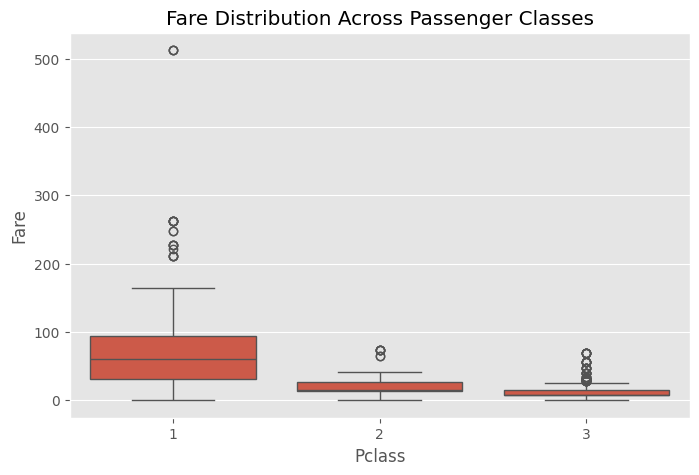

In [57]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Pclass",
    y="Fare"
)

plt.title("Fare Distribution Across Passenger Classes")

plt.show()

### Interpretation

Ticket fares differ substantially across passenger classes. First-class passengers generally paid considerably higher fares than third-class passengers.

This relationship suggests that fare and passenger class capture similar socioeconomic characteristics, although each variable may still provide complementary information.

## Age Distribution Across Passenger Classes

Examining age distributions across classes provides insight into demographic differences among passenger groups.

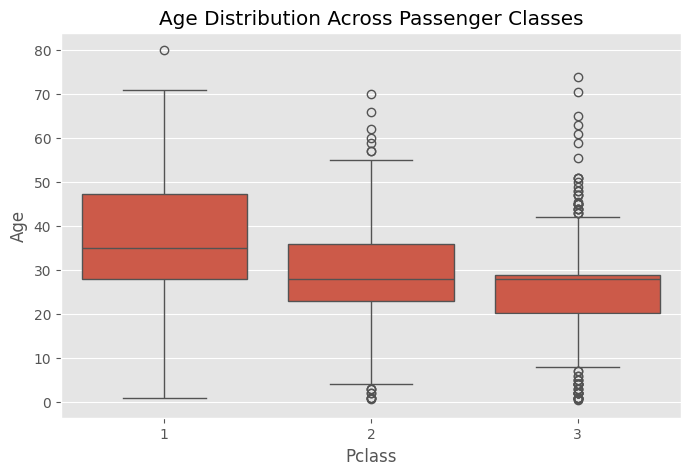

In [58]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Pclass",
    y="Age"
)

plt.title("Age Distribution Across Passenger Classes")

plt.show()

### Interpretation

Age distributions vary across passenger classes, indicating that socioeconomic groups are not demographically identical.

These differences suggest that interactions involving age and passenger class may contribute additional predictive value.

## Family Structure

The variables `SibSp` and `Parch` describe different aspects of family relationships aboard the Titanic. Examining their joint distribution helps identify opportunities for constructing more informative features.

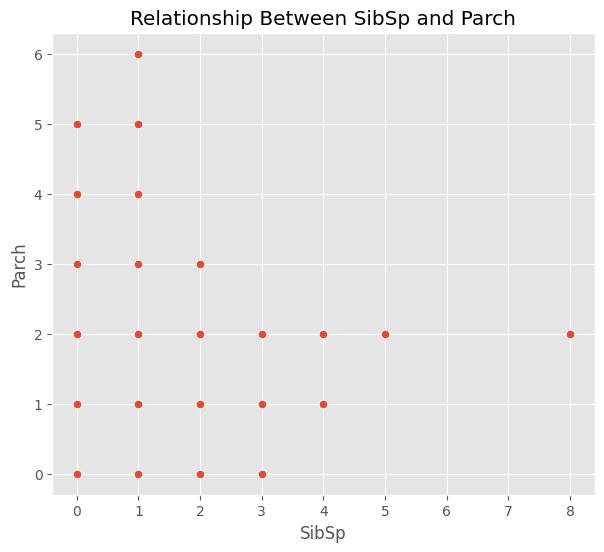

In [59]:
plt.figure(figsize=(7,6))

sns.scatterplot(
    data=df,
    x="SibSp",
    y="Parch"
)

plt.title("Relationship Between SibSp and Parch")

plt.show()

### Interpretation

Most passengers traveled with relatively few family members aboard. The individual family-related variables contain limited information when considered independently, suggesting that combining them into a single measure of family size may better capture family structure.

This observation motivates the creation of engineered variables such as `FamilySize` and `IsAlone`.

## Correlation Analysis

Understanding relationships among numerical variables helps identify dependencies, redundancy, and potential interactions.

Correlation analysis does not establish causation, but it provides a useful overview of the linear associations present within the dataset.

In [60]:
numerical_features = df.select_dtypes(
    include=np.number
).columns

correlation_matrix = df[numerical_features].corr()

correlation_matrix

,Survived,Pclass,Age,SibSp,Parch,Fare
Survived,1.000000,-0.338481,-0.064910,-0.035322,0.081629,0.257307
Pclass,-0.338481,1.000000,-0.339898,0.083081,0.018443,-0.549500
Age,-0.064910,-0.339898,1.000000,-0.233296,-0.172482,0.096688
SibSp,-0.035322,0.083081,-0.233296,1.000000,0.414838,0.159651
Parch,0.081629,0.018443,-0.172482,0.414838,1.000000,0.216225
Fare,0.257307,-0.549500,0.096688,0.159651,0.216225,1.000000


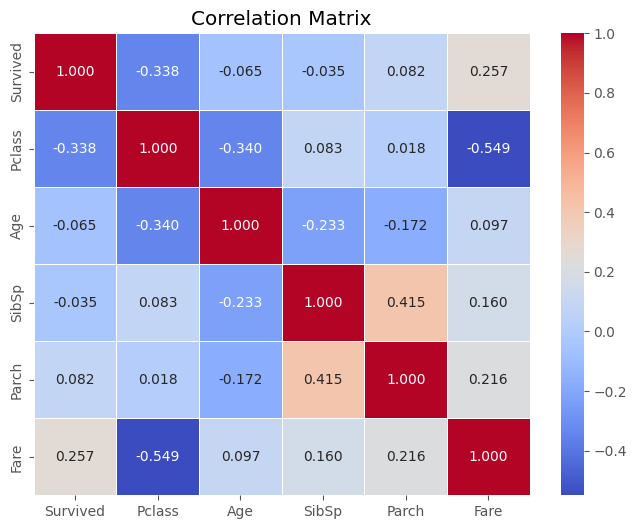

In [61]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".3f",
    linewidths=0.5
)

plt.title("Correlation Matrix")

plt.show()

### Interpretation

Most numerical variables exhibit weak to moderate correlations, suggesting that the dataset does not suffer from severe multicollinearity.

The strongest associations with survival are observed for passenger class and fare, indicating that socioeconomic characteristics likely played an important role in determining survival outcomes.

Since correlation captures only linear relationships, weak correlations should not be interpreted as evidence that a variable lacks predictive value.

## Multivariate Analysis

Individual relationships rarely operate in isolation. Examining multiple variables simultaneously provides a more comprehensive understanding of survival patterns and interaction effects.

This section focuses on how demographic and socioeconomic characteristics jointly influenced passenger outcomes.

## Survival Patterns Across Gender and Passenger Class

Gender and passenger class are among the strongest individual predictors of survival. Investigating their combined influence helps reveal whether survival advantages were uniformly distributed across socioeconomic groups.

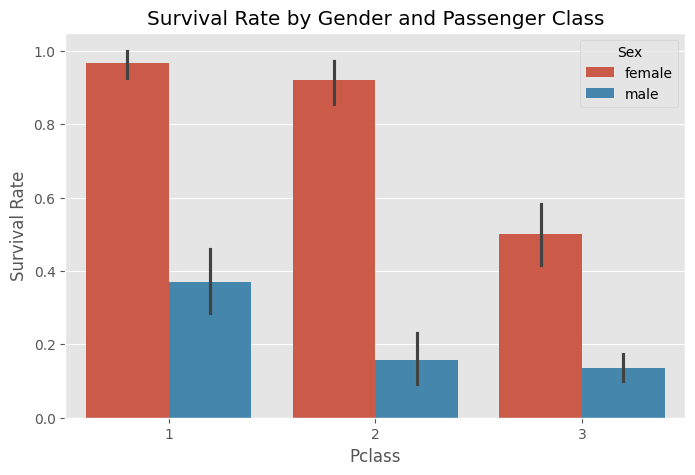

In [62]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Pclass",
    y="Survived",
    hue="Sex"
)

plt.ylabel("Survival Rate")

plt.title("Survival Rate by Gender and Passenger Class")

plt.show()

### Interpretation

Survival outcomes vary substantially across both gender and passenger class. Female passengers consistently exhibit higher survival rates, with first-class women experiencing the most favorable outcomes.

Conversely, third-class male passengers experienced the lowest survival rates. These findings indicate that demographic and socioeconomic factors interacted rather than acting independently.

## Age Distribution Across Gender and Survival

Examining age distributions jointly with gender and survival provides insight into whether age-related effects differed between male and female passengers.

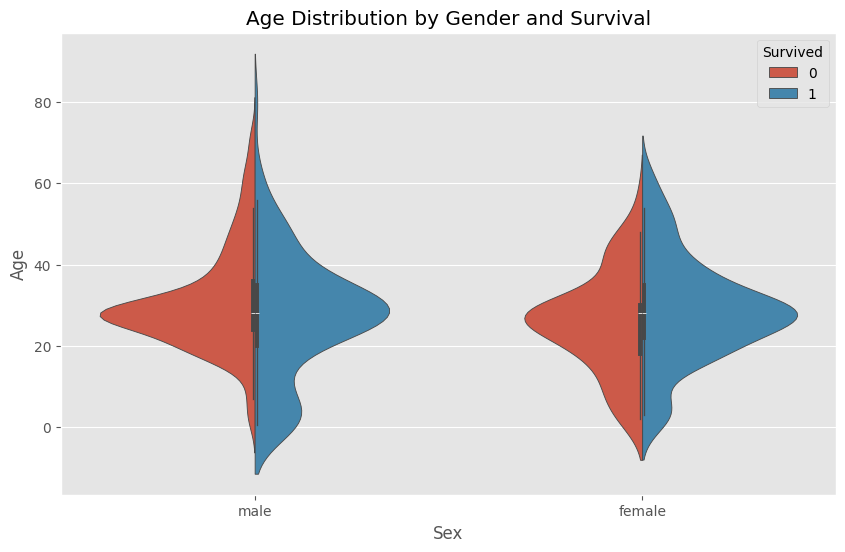

In [63]:
plt.figure(figsize=(10,6))

sns.violinplot(
    data=df,
    x="Sex",
    y="Age",
    hue="Survived",
    split=True
)

plt.title("Age Distribution by Gender and Survival")

plt.show()

### Interpretation

Age distributions overlap considerably across groups, although younger passengers appear to exhibit a modest survival advantage.

The observed patterns suggest that age-related effects are likely nonlinear and may interact with demographic characteristics.

## Relationship Between Fare, Passenger Class, and Survival

Ticket fare and passenger class both capture aspects of socioeconomic status. Examining these variables jointly helps determine whether they provide complementary information.

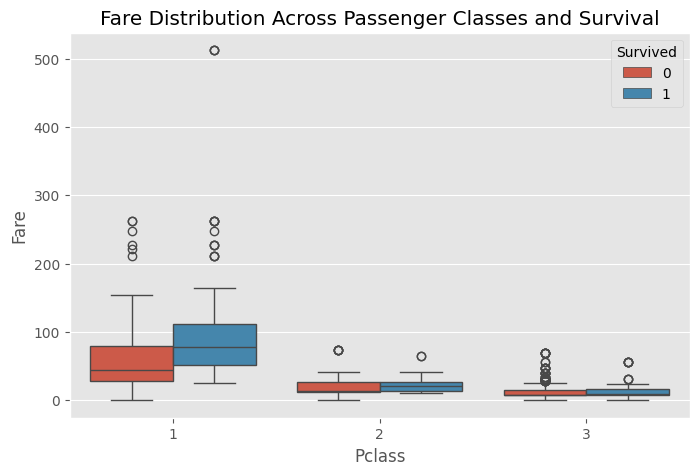

In [64]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Pclass",
    y="Fare",
    hue="Survived"
)

plt.title("Fare Distribution Across Passenger Classes and Survival")

plt.show()

### Interpretation

Passengers with higher fares generally experienced higher survival rates, particularly within the upper classes.

These findings suggest that fare and passenger class contain overlapping yet complementary information, both of which are expected to contribute to predictive performance.

## Family Structure and Survival

Family-related variables may capture social and behavioral factors that individual demographic variables fail to represent.

Understanding these relationships may reveal opportunities for feature engineering.

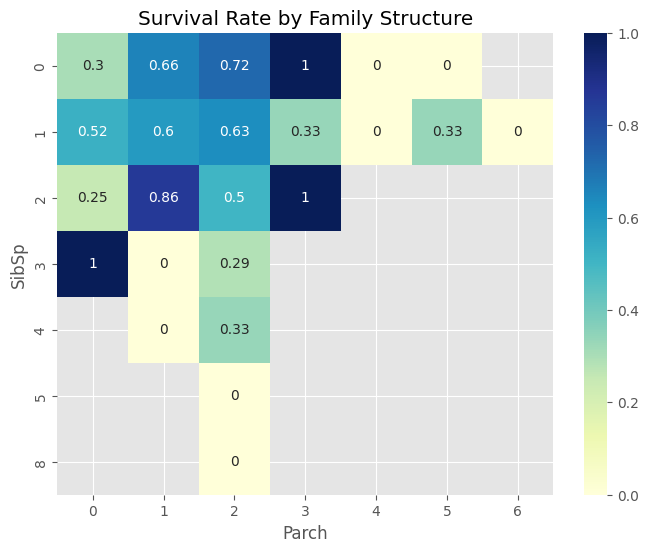

In [65]:
family_survival = pd.pivot_table(
    df,
    values="Survived",
    index="SibSp",
    columns="Parch",
    aggfunc="mean"
)

plt.figure(figsize=(8,6))

sns.heatmap(
    family_survival,
    annot=True,
    cmap="YlGnBu"
)

plt.title("Survival Rate by Family Structure")

plt.show()

### Interpretation

Survival patterns vary across different family configurations. Extreme family sizes appear less favorable, while moderate family sizes exhibit relatively higher survival rates.

These observations suggest that family structure contains information that may not be fully captured by `SibSp` and `Parch` individually.

## Multivariate Findings

Several interaction effects emerge from the analysis:

- Gender and passenger class jointly exert a strong influence on survival outcomes.
- Female passengers, particularly those in higher classes, experienced the most favorable outcomes.
- Third-class male passengers exhibited the lowest survival rates.
- Ticket fare and passenger class provide complementary socioeconomic information.
- Family structure appears to influence survival and motivates additional feature engineering.

These findings suggest that survival aboard the Titanic was shaped by the interaction of demographic, economic, and family-related characteristics rather than by any single variable in isolation.